## **Regression and Data Simulation**
---

This assignment investigates regression modeling through data simulation and statistical analysis. Different linear and non-linear models are fitted and compared to study model behavior, regularization effects, and the bias–variance trade-off. The goal is to understand how model complexity, data size, and noise influence prediction, stability, and generalization performance.

**Import libraires**

In [ ]:
# ------------------------------
# Data Manipulation
# ------------------------------
import numpy as np
import pandas as pd

# ------------------------------
# Visualization
# ------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# Statistical Modeling
# ------------------------------
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from patsy import dmatrix
# ------------------------------
# Machine Learning & Regression
# ------------------------------
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  RidgeCV, LassoCV, ElasticNetCV)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error


## **1. DATA SET SIMULATION AND LINEAR REGRESSION**



### **1.1. Start by simulating data from a linear function with p=10 and n=300, where only some have meaningful effects (associate large coefficients to a few variables and to the remaining ones smaller or null coefficients, you choose the coefficients). Write down your chosen function and justify your choices. Comment on randomness and error.**

In [ ]:
np.random.seed(42)

n = 300
p = 10

X = np.random.normal(0, 1, (n, p))
beta = np.array([6, 4, 3, 0, 0.05, 0, 0, 0, 0, 0.02])
epsilon = np.random.normal(0, 1, n)
y = X @ beta + epsilon # linear equation

In [ ]:
X

array([[ 0.49671415, -0.1382643 ,  0.64768854, ...,  0.76743473,
        -0.46947439,  0.54256004],
       [-0.46341769, -0.46572975,  0.24196227, ...,  0.31424733,
        -0.90802408, -1.4123037 ],
       [ 1.46564877, -0.2257763 ,  0.0675282 , ...,  0.37569802,
        -0.60063869, -0.29169375],
       ...,
       [-1.91225498, -0.06863405, -1.36831504, ..., -0.84631598,
         0.54347938,  0.19981043],
       [ 0.26402008,  1.2723535 ,  0.7324921 , ...,  0.09337237,
        -1.13020372,  2.41167668],
       [ 1.51639406,  0.60211832,  0.07203686, ..., -1.24176058,
         0.33417642, -0.15525905]])

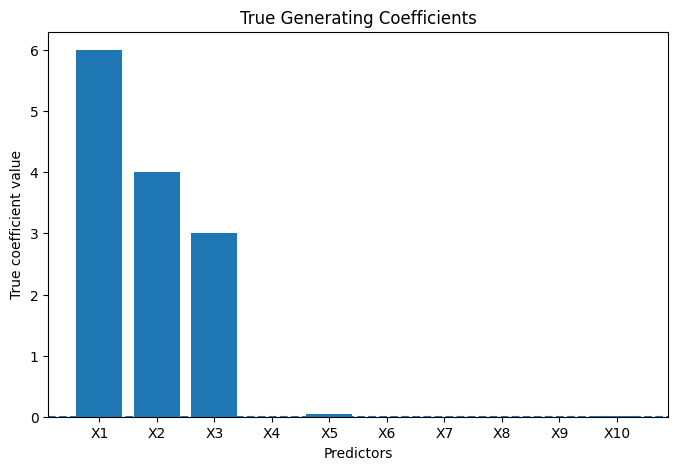

In [ ]:
variables = [f'X{i+1}' for i in range(p)]

plt.figure(figsize=(8,5))
plt.bar(variables, beta)
plt.axhline(0, linestyle='--')
plt.xlabel('Predictors')
plt.ylabel('True coefficient value')
plt.title('True Generating Coefficients')
plt.show()

* We simulate a dataset with
**𝑛 = 300**  observations and **𝑝=10** predictors generated independently from a standard normal distribution.
* Only the first three predictors have a true effect on the response variable, with coefficients set to 6, 4, and 3 respectively, while the remaining coefficients are set to zero or small values to represent irrelevant features.

* A Gaussian noise term with mean zero and unit variance is added to account for random variability.


###  **1.2. Fit a Linear Regression model on the simulated dataset. Report estimated coefficients, standard errors, p-values, t-statistics, etc…**



Ordinary Least Squares(OLS), estimates cofficient by minimizing the sum of squared residuals

In [ ]:
model = LinearRegression()
model.fit(X, y)

coef = model.coef_

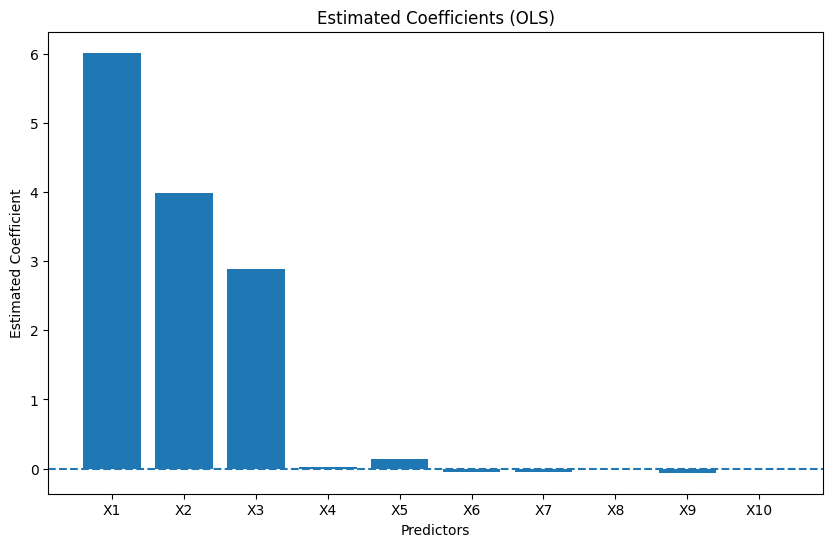

In [ ]:
variables = [f'X{i+1}' for i in range(len(coef))]

plt.figure(figsize=(10,6))
plt.bar(variables, coef)
plt.axhline(0, linestyle='--')
plt.xlabel('Predictors')
plt.ylabel('Estimated Coefficient')
plt.title('Estimated Coefficients (OLS)')
plt.show()

In [ ]:
X_sm = sm.add_constant(X) #adds the intercept coefficient B0
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     1723.
Date:                Mon, 09 Feb 2026   Prob (F-statistic):          4.88e-251
Time:                        22:05:58   Log-Likelihood:                -430.19
No. Observations:                 300   AIC:                             882.4
Df Residuals:                     289   BIC:                             923.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0550      0.061     -0.903      0.3


The **linear regression** model shows an excellent overall fit.

* The R-Squared = 0.983, indicates that 98.3% of the variability in the response variable 𝑦 is explained by the predictors.

* The adjusted 𝑅-squared = 0.983, is almost identical, suggesting that adding predictors does not artificially inflate model performance.

* The F-statistic = 1723 with a small p-value
 strongly rejects the null hypothesis that all regression coefficients are zero.
This confirms that the model is statistically significant as a whole.

* x1: Coefficient = 6.01, 𝑝 < 0.05, Strong positive effect on
𝑦.

* 𝑥2: Coefficient = 3.98, 𝑝 < 0.05, Strong positive effect.

* 𝑥3: Coefficient = 2.89, 𝑝 < 0.05, Significant positive contribution.

* 𝑥5: Coefficient = 0.13, 𝑝 = 0.025, p=0.025, Small but statistically significant effect.

* These results indicate that the model successfully identifies the predictors with meaningful influence on the response variable.

* The remaining variables (𝑥4, 𝑥6, 𝑥7, 𝑥8, 𝑥9, 𝑥10) have large p-values (𝑝>0.05):

  * Their estimated coefficients are close to zero

  * They do not contribute significantly to explaining 𝑦.

  * This suggests that these variables are likely noise predictors, which is consistent with a data-generating process where only a subset of variables has true effects.


### **1.3. Which predictors appear statistically significant? Do the significant variables match the ones you originally set with strong coefficients?**



> The linear regression results show that only the first three predictors (x1, x2, x3) are statistically significant, with p-values close to zero.
This matches the data-generating process, since these 3 coefficients have high values (effect) on y, big t value, and small p-value.
Therefore, the model successfully identified the true influential variables.



### **1.4. Using the residuals perform a regression diagnostic on the model.**


In [ ]:
y_pred = model.predict(X)
residuals = y - y_pred

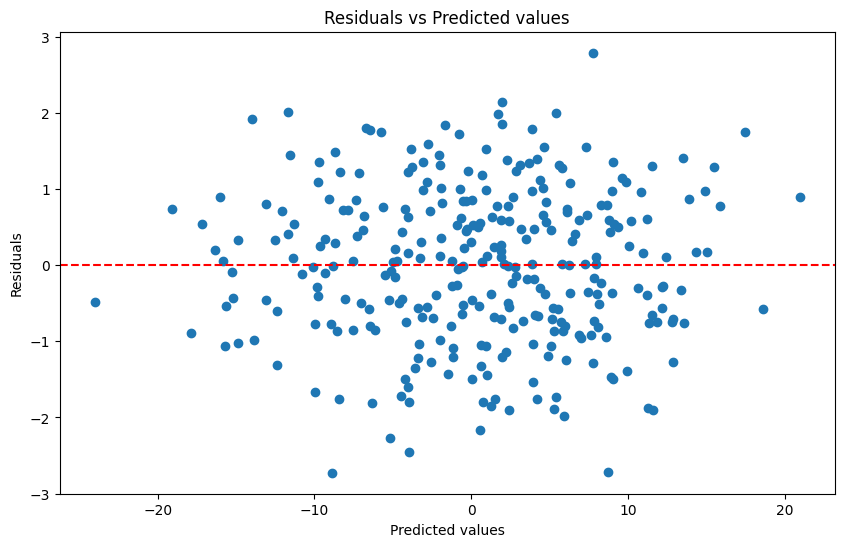

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted values")
plt.show()

$$
e_i = y_i - \hat{y}_i
$$
$y_i$ = observed value

$\hat{y}_i$ = value predicted by the regression model

$e_i$ = residual

* The dots are randomly scattered around the red zero line (ei = 0)
* There is no clear pattern (no curve, no wave, no funnel shape)
* Residuals are spread both above and below zero
* This means that the model is not systematically over or under-predicting and it's behaving well
* Relationship looks linear




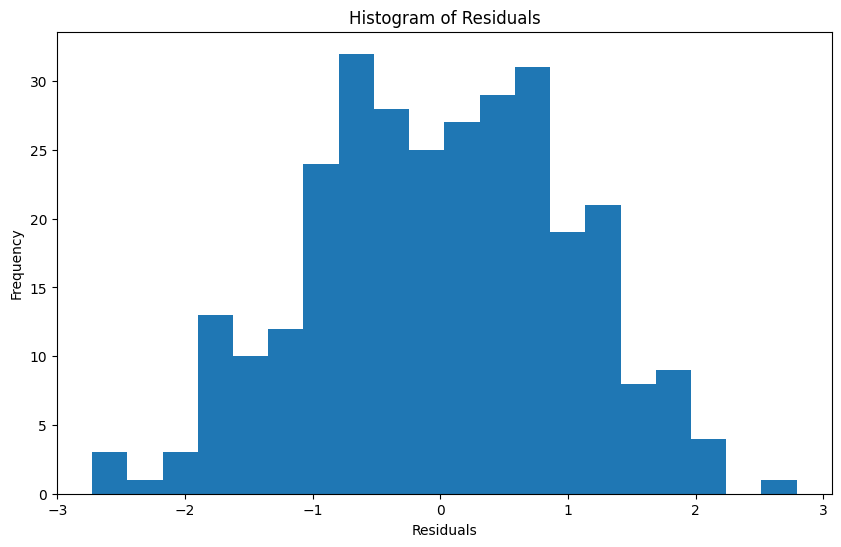

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(residuals, bins=20)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

<Figure size 1000x600 with 0 Axes>

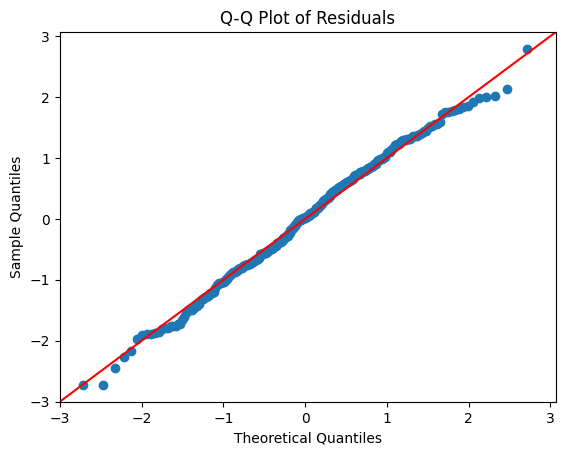

In [ ]:
plt.figure(figsize=(10,6))
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()


from plot we see that all residuals follow a straight line, normal distripution

### **1.5. Identify high leverage points, influential observations and outliers. Comment on how they might effect model stability.**

In [ ]:
influence = model_sm.get_influence() #creates an object that contains: Leverage values, Cook's distance, and Studentized residuals

leverage = influence.hat_matrix_diag      # high leverage

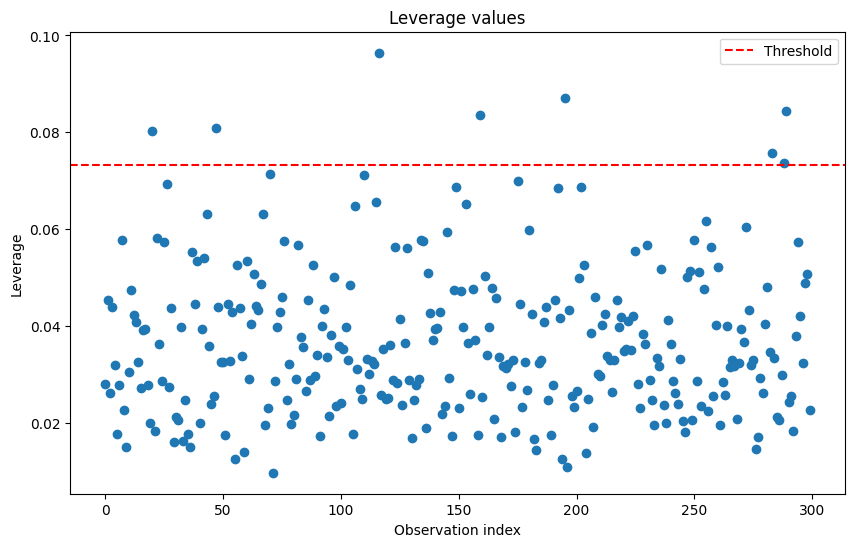

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(leverage)), leverage)
plt.axhline(2*X_sm.shape[1]/X_sm.shape[0], color='red', linestyle='--', label='Threshold')
plt.xlabel("Observation index")
plt.ylabel("Leverage")
plt.title("Leverage values")
plt.legend()
plt.show()

* Observation Index (X-axis): This represents each individual row or data point in your dataset (from 0 to roughly 300).
* Leverage (Y-axis): This value (often denoted as $h_{ii}$) ranges from $1/n$ to $1$. Higher values indicate the point is an outlier in the predictor space.
* Red Dashed Line (Threshold): This is a critical diagnostic boundary. A common rule of thumb for this threshold is $3p/n$ or $2p/n$ (where $p$ is the number of predictors and $n$ is the sample size).
* About 8 points have high leverage, meaning they have a stronger-than-average impact on the model's "slope."

In [ ]:
#cook's distance measures how much the regression model changes if you remove one observation
cooks = influence.cooks_distance[0]       # influential points

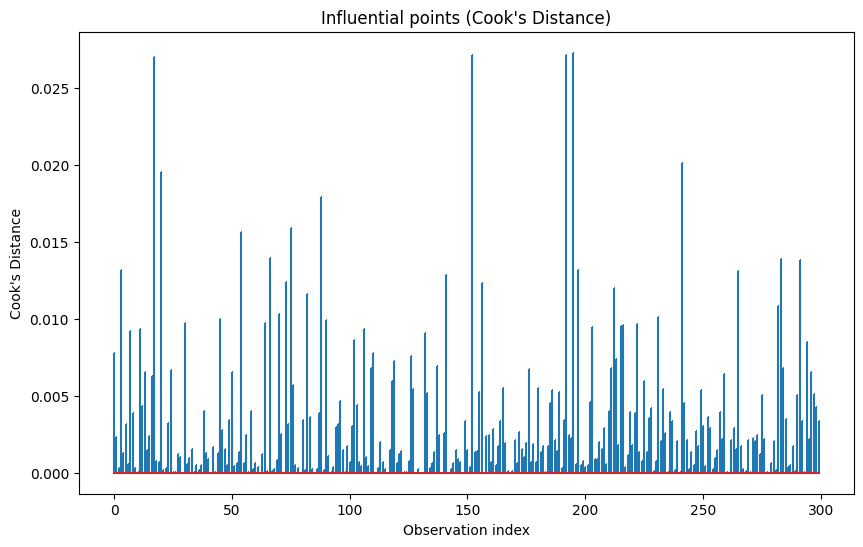

In [ ]:
plt.figure(figsize=(10,6))
plt.stem(range(len(cooks)), cooks, markerfmt=",")
plt.xlabel("Observation index")
plt.ylabel("Cook's Distance")
plt.title("Influential points (Cook's Distance)")
plt.show()

* Most observations have very low Cook’s Distance values, indicating that they have minimal influence on the regression model.

* The model appears stable, as no single observation dominates the regression results.

* A few observations show relatively higher Cook’s Distance values, suggesting the presence of potentially influential points.

* These influential points may slightly affect model parameters, but they do not critically distort the overall model.

* No Cook’s Distance values exceed critical thresholds (e.g.,
𝐷>1), indicating the absence of highly influential outliers.

* Overall, the regression model is robust and not overly sensitive to individual data points.

In [ ]:
student_resid = influence.resid_studentized_external  # outliers

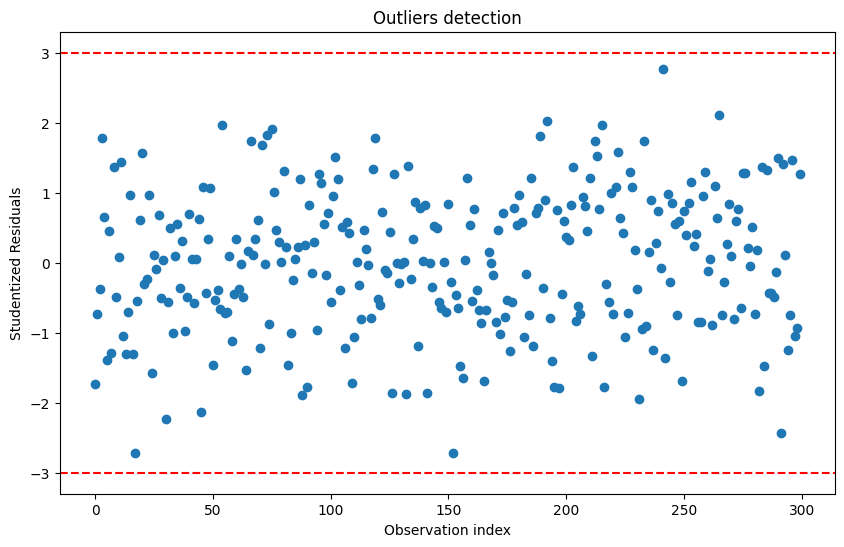

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(student_resid)), student_resid)
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.xlabel("Observation index")
plt.ylabel("Studentized Residuals")
plt.title("Outliers detection")
plt.show()

* Almost all points fall within the red dashed lines at -3 and 3.

## **2. SHRINKAGE AND REGULARIZATION**


### **2.1. Using the same dataset fit a Ridge Regression model. Use cross-validation to select the optimal lambda. Plot the coefficient paths. How much different are the estimated coefficients from the true generating ones?**

Standardization

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Ridge Regression

In [ ]:
alphas = np.logspace(-3, 3, 100)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_scaled, y)

RidgeCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5)

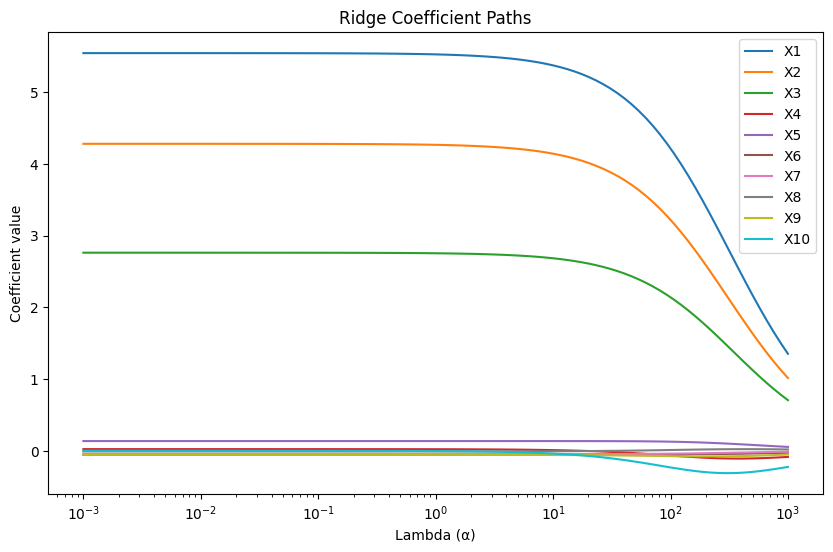

In [ ]:
coefs = []
for a in alphas:
    ridge_tmp = Ridge(alpha=a)
    ridge_tmp.fit(X_scaled, y)
    coefs.append(ridge_tmp.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
for i in range(X.shape[1]):
    plt.plot(alphas, coefs[:, i], label=f'X{i+1}')
plt.xscale('log')
plt.xlabel('Lambda (α)')
plt.ylabel('Coefficient value')
plt.title('Ridge Coefficient Paths')
plt.legend()
plt.show()

**Ridge Regression Formula:**
$$
\min_{\beta}
\left[
\sum_{i=1}^{n} (y_i - X_i \beta)^2
+
\lambda \sum_{j=1}^{p} \beta_j^2
\right]
$$
- $
\sum_{i=1}^{n} (y_i - X_i \beta)^2
$: **Least Squares Error Term**, that measures how well the model fits the data
- $
\sum_{j=1}^{p} \beta_j^2
$: **Ridge Penalty Term**, that penalizes large coefficient values
- $
\lambda
$: **Regularization Parameter**, that controls the strength of the penalty



- The model was trained using **5-fold cross-validation**.
- Different values of the penalty parameter were tested in the range  
  $\lambda \in [10^{-3},\,10^{3}]$

- The best value of $\lambda$ was selected to balance:
  - Model simplicity  .
  - Prediction accuracy .

**Compared to Ordinary Least Squares (OLS):**
- Ridge shrinks the coefficients (makes them smaller).
- It reduces variance (model becomes more stable).
- It keeps all variables in the model (no variable is removed).

**Effect on variables:**
- Important variables: still strong and clear.
- Unimportant variables: heavily reduced (penalized).


### **2.2. Fit a Lasso Regression model. Use cross-validation to select the optimal lambda. Plot the coefficient paths. Which coefficients shrunk exactly to zero? Compare variable selection with your true generating beta.**

In [ ]:
lasso = LassoCV(alphas=alphas, cv=5)
lasso.fit(X_scaled, y)

LassoCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5)

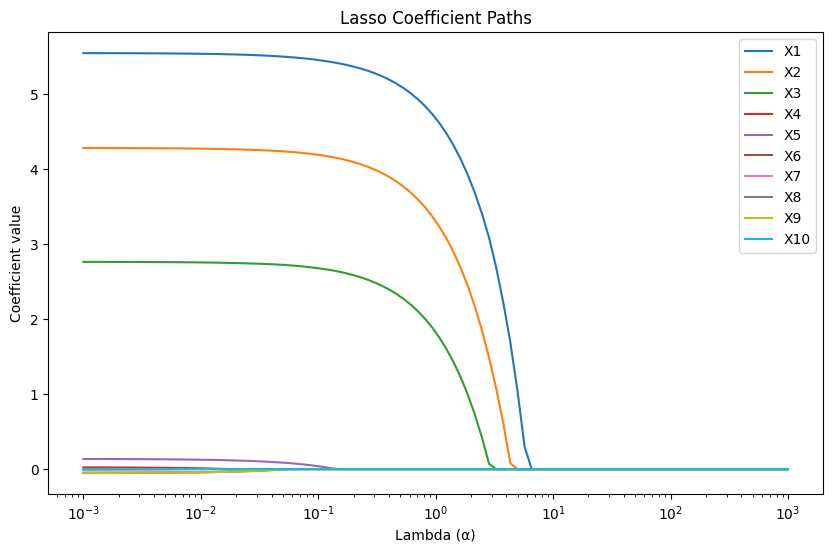

In [ ]:
coefs = []
for a in alphas:
    lasso_tmp = Lasso(alpha=a, max_iter=10000)
    lasso_tmp.fit(X_scaled, y)
    coefs.append(lasso_tmp.coef_)

coefs = np.array(coefs)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for i in range(X.shape[1]):
    plt.plot(alphas, coefs[:, i], label=f'X{i+1}')
plt.xscale('log')
plt.xlabel('Lambda (α)')
plt.ylabel('Coefficient value')
plt.title('Lasso Coefficient Paths')
plt.legend()
plt.show()

**Lasso Formula:**
$$
\hat{\beta}^{\text{lasso}}
=
\arg\min_{\beta}
\left[
\sum_{i=1}^{n} (y_i - X_i \beta)^2
+
\lambda \sum_{j=1}^{p} |\beta_j|
\right]
$$

- The $|\beta_j|$ is the different part from Ridge Regression.

- Lasso regression was fitted using **5-fold cross-validation**.
- A logarithmic grid of penalty parameters was tested in the range:  
  $\lambda \in [10^{-3},\,10^{3}]$

- The optimal value of $\lambda$ was selected by **minimizing the cross-validated mean squared error (MSE)**.

- Unlike Ridge regression, Lasso uses an $\ell_1$ penalty:
  - This allows some coefficients to shrink **exactly to zero**.
  - As a result, Lasso performs **automatic variable selection**.

**Effect on variables:**
- Predictors with strong true effects: retain **non-zero coefficients**  
- Irrelevant variables are **excluded from the model** (coefficients = 0)

### **2.3. Fit an Elastic-Net Regression model. Use cross-validation to find the optimal combination of alpha and lambda (you can do this either with grid-search or with a graphical approach).**

In [ ]:
elastic = ElasticNetCV(l1_ratio=[.1, .5, .9], alphas=alphas, cv=5)
elastic.fit(X_scaled, y)

ElasticNetCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.873817...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
             cv=5, l1_ratio=[0.1, 0.5, 0.9])

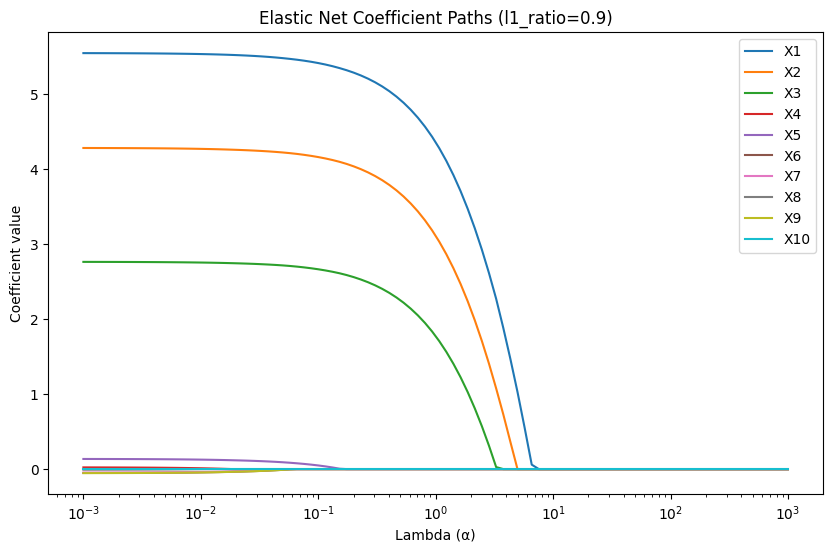

In [ ]:
coefs = []
for a in alphas:
    tmp = ElasticNet(alpha=a, l1_ratio=elastic.l1_ratio_, max_iter=10000)
    tmp.fit(X_scaled, y)
    coefs.append(tmp.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
for i in range(X.shape[1]):
    plt.plot(alphas, coefs[:, i], label=f'X{i+1}')
plt.xscale('log')
plt.xlabel('Lambda (α)')
plt.ylabel('Coefficient value')
plt.title(f'Elastic Net Coefficient Paths (l1_ratio={elastic.l1_ratio_})')
plt.legend()
plt.show()

- Elastic Net regression was fitted using **5-fold cross-validation**.
- A logarithmic grid of penalty parameters was tested in the range:  
  $\lambda \in [10^{-3},\,10^{3}]$

- The model selected:
  - The regularization parameter $\lambda$
  - The mixing parameter $\alpha \in \{0.1,\,0.5,\,0.9\}$

- $\alpha$ controls the balance between:
  - $\ell_1$ penalty (Lasso)
  - $\ell_2$ penalty (Ridge)

**Elastic Net properties:**
- Combines **Ridge + Lasso**
- Performs **coefficient shrinkage**
- Performs **variable selection**

**Effect on variables:**
- Strong predictors: **preserved**
- Irrelevant predictors:**attenuated or removed**

## **3. NON-LINEAR REGRESSION AND BIAS-VARIANCE EXPERIMENT**

### **3.1. Chose a new generating function that is not linear (exponential, polynomial, trigonometric or a combination) and simulate a dataset with p = 1 and n = 10. Plot the true generating function and the observed points.**

Non-linear trigonometric (sinusoidal) function:$y = \sin(2\pi x) + \varepsilon$


In [ ]:
np.random.seed(42)

n = 10
X = np.sort(np.random.uniform(0, 1, n))
true_function = np.sin(2 * np.pi * X)
noise = np.random.normal(loc=0.0, scale=0.1, size=n)
y = true_function + noise

In [ ]:
X_plot = np.linspace(0, 1, 100)
y_true = np.sin(2 * np.pi * X_plot)

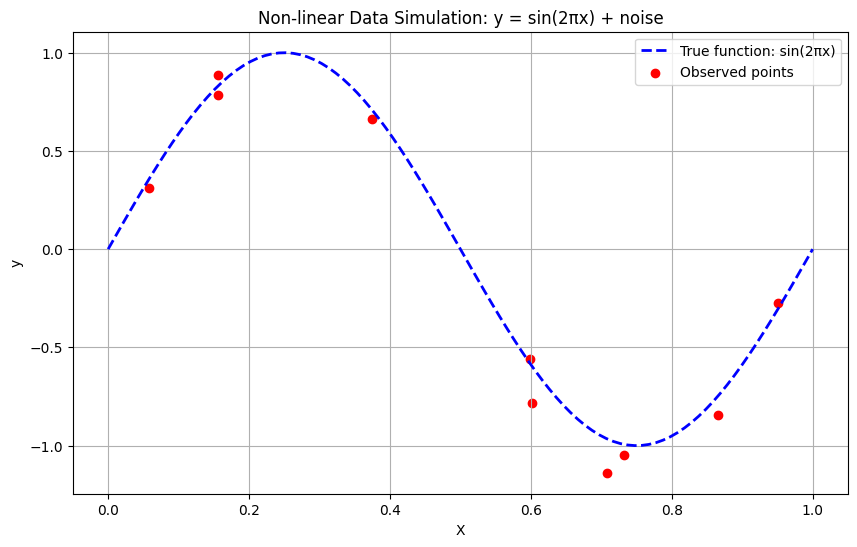

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(X_plot, y_true, color='blue', linestyle='--', linewidth=2, label='True function: sin(2πx)')
plt.scatter(X, y, color='red', label='Observed points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Non-linear Data Simulation: y = sin(2πx) + noise')
plt.grid(True)
plt.legend()
plt.show()

### **3.2. Fit two polynomial regression models: one with a degree lower than 10 and one with degree equal to ten. Plot both regression curves, the true generating function and the observed points. What do you notice? Which model yields the lowest train error? Which model is closer to the true generating function? Why does the 10 degrees polynomial regression interpolates all points? Describe and comment the bias-variance trade-off in this context.**

Fit polynomial regression model with low degree

In [ ]:
degree_low = 3
poly_low = PolynomialFeatures(degree=degree_low)
X_poly_low = poly_low.fit_transform(X.reshape(-1,1))
model_low = LinearRegression()
model_low.fit(X_poly_low, y)
y_pred_low = model_low.predict(poly_low.transform(X_plot.reshape(-1,1)))

Fit polynomial regression model with high degree

In [ ]:
degree_high = 10
poly_high = PolynomialFeatures(degree=degree_high)
X_poly_high = poly_high.fit_transform(X.reshape(-1,1))
model_high = LinearRegression()
model_high.fit(X_poly_high, y)
y_pred_high = model_high.predict(poly_high.transform(X_plot.reshape(-1,1)))

Plot both regression curves

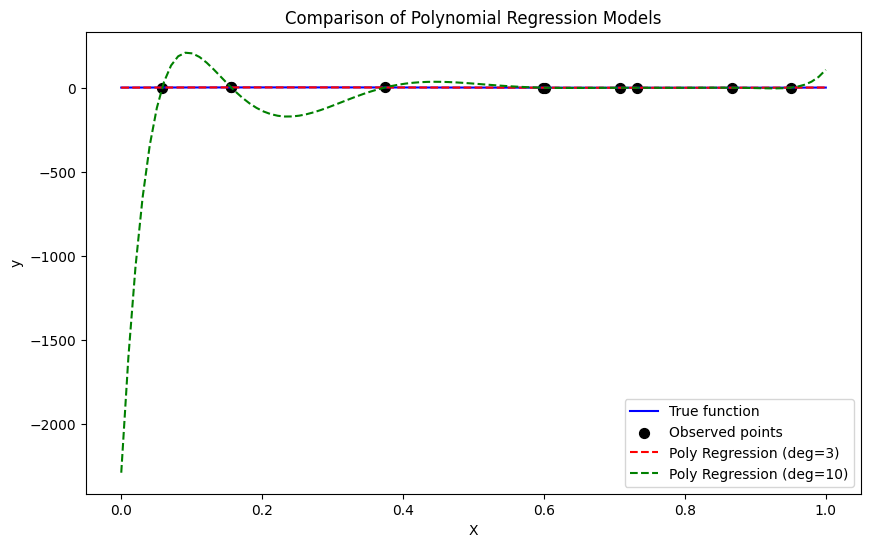

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(X_plot, y_true, color='blue', label='True function')
plt.scatter(X, y, color='black', s=50, label='Observed points')
plt.plot(X_plot, y_pred_low, color='red', linestyle='--', label=f'Poly Regression (deg={degree_low})')
plt.plot(X_plot, y_pred_high, color='green', linestyle='--', label=f'Poly Regression (deg={degree_high})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparison of Polynomial Regression Models')
plt.legend()
plt.show()

Compute and Compare MSE for both

In [ ]:
mse_low = mean_squared_error(y, model_low.predict(X_poly_low))
mse_high = mean_squared_error(y, model_high.predict(X_poly_high))

print(f"Train MSE (degree {degree_low}): {mse_low:.4f}")
print(f"Train MSE (degree {degree_high}): {mse_high:.4f}")

Train MSE (degree 3): 0.0052
Train MSE (degree 10): 0.0000


* Red line (deg=3): Simple curve → Underfitting, follows general shape, better generalization

* Green line (deg=10): Complex curve, Overfitting, passes all points, poor generalization

* Lowest training error: deg=10, fits all points, training error ≈ 0

* Closest to true function: deg=3, captures general sine shape, ignores noise

* Why deg=10 fits all points: Number of coefficients ≈ number of points, interpolation (zero training error but high variance)


### **3.3. Using the same underlying function simulate a new dataset with p = 1 and n > 100. Fit again the 10 degrees polynomial regression model. Plot and compre the two 10 degrees polynomial regression lines. Which model presents a less extreme overfitting? Comment on why.**

In [ ]:
np.random.seed(42)

n_small = 10
n_large = 150

X_small = np.random.uniform(0, 1, n_small)
y_small = np.sin(2 * np.pi * X_small) + np.random.normal(0, 0.1, n_small)

X_large = np.random.uniform(0, 1, n_large)
y_large = np.sin(2 * np.pi * X_large) + np.random.normal(0, 0.1, n_large)

X_plot = np.linspace(0, 1, 200)
y_true = np.sin(2 * np.pi * X_plot)

In [ ]:
degree = 10

def fit_poly_regression(X, y, degree):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X.reshape(-1,1))
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    return poly, model, y_pred

poly_small, model_small, y_pred_small = fit_poly_regression(X_small, y_small, degree)
poly_large, model_large, y_pred_large = fit_poly_regression(X_large, y_large, degree)

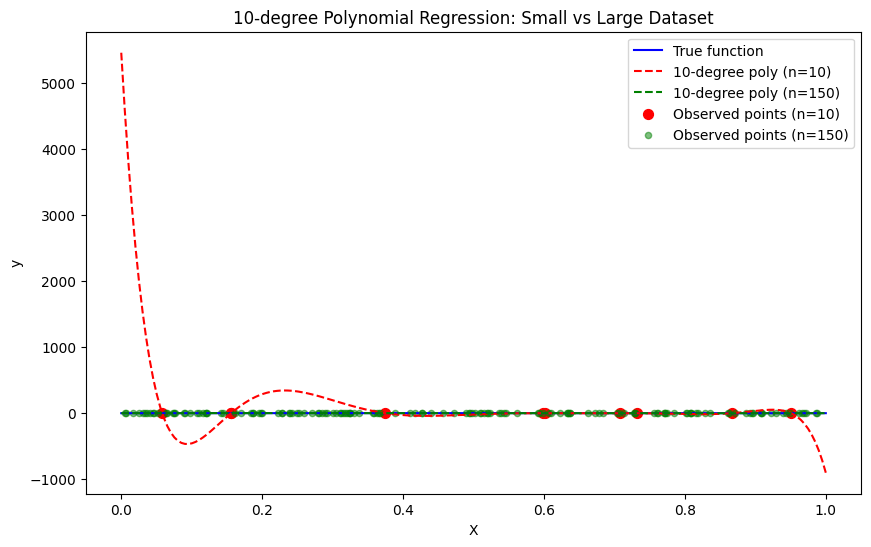

In [ ]:
X_plot_poly_small = poly_small.transform(X_plot.reshape(-1,1))
y_plot_small = model_small.predict(X_plot_poly_small)

X_plot_poly_large = poly_large.transform(X_plot.reshape(-1,1))
y_plot_large = model_large.predict(X_plot_poly_large)

plt.figure(figsize=(10,6))

plt.plot(X_plot, y_true, color='blue', label='True function')
plt.plot(X_plot, y_plot_small, color='red', linestyle='--', label='10-degree poly (n=10)')
plt.plot(X_plot, y_plot_large, color='green', linestyle='--', label='10-degree poly (n=150)')

plt.scatter(X_small, y_small, color='red', s=50, label='Observed points (n=10)')
plt.scatter(X_large, y_large, color='green', s=20, label='Observed points (n=150)', alpha=0.5)

plt.xlabel('X')
plt.ylabel('y')
plt.title('10-degree Polynomial Regression: Small vs Large Dataset')
plt.legend()
plt.show()


* Red line (n=10 points, 10-degree poly):
  * Fits every point exactly, extreme oscillations
  * Extreme overfitting, very high variance

* Green line (n=150 points, 10-degree poly):
  * Cannot pass through every point.

  * Smoother, follows the true function better.

  * Less extreme overfitting, lower variance.

* Small dataset: number of points ≈ number of coefficients , then the model can interpolate every point, high variance

* Large dataset: number of points ≫ number of coefficients, then the model balances fitting and smoothness (reduced overfitting).

* More data reduces overfitting for complex models.

* Increasing dataset size stabilizes high-degree polynomial fits.

### **3.4. Using the same dataset, fit non-linear regression models selected among those proposed during lecture. Find the optimal parameters (depending on the selected models). Compare the fitted curves and the true generating function. Compare performances among the models.**

**Polynomial Regression**

In [ ]:
degree = 4
poly = PolynomialFeatures(degree=degree)

X_poly = poly.fit_transform(X.reshape(-1,1))
model_poly = LinearRegression().fit(X_poly, y)

y_poly = model_poly.predict(poly.transform(X_plot.reshape(-1,1)))

**Spline Regression (Cubic Spline)**

In [ ]:
# Spline basis
spline_basis = dmatrix(
    "bs(x, df=10, degree=3, include_intercept=False)",
    {"x": X},
    return_type='dataframe'
)

model_spline = LinearRegression().fit(spline_basis, y)

# Prediction
spline_plot = dmatrix(
    "bs(x, df=10, degree=3, include_intercept=False)",
    {"x": X_plot},
    return_type='dataframe'
)

y_spline = model_spline.predict(spline_plot)

**Local Regression (LOESS)**

In [ ]:
loess_result = lowess(y, X, frac=0.25)

X_loess = loess_result[:,0]
y_loess = loess_result[:,1]

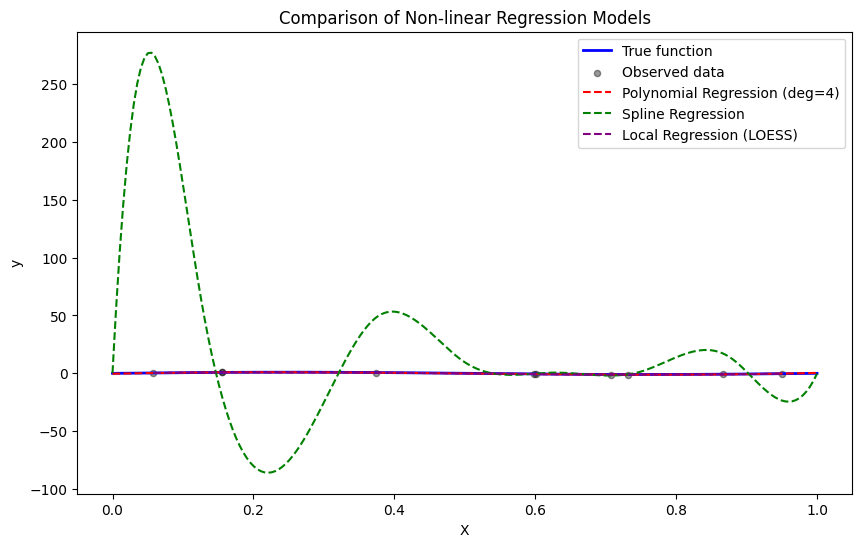

In [ ]:
plt.figure(figsize=(10,6))

# True function
plt.plot(X_plot, y_true, label='True function', color='blue', linewidth=2)

# Observed points
plt.scatter(X, y, label='Observed data', color='black', s=20, alpha=0.4)

# Models
plt.plot(X_plot, y_poly, '--', label='Polynomial Regression (deg=4)', color='red')
plt.plot(X_plot, y_spline, '--', label='Spline Regression', color='green')
plt.plot(X_loess, y_loess, '--', label='Local Regression (LOESS)', color='purple')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparison of Non-linear Regression Models')
plt.legend()
plt.show()

In [ ]:
# Predictions on training data
y_poly_train = model_poly.predict(X_poly)
y_spline_train = model_spline.predict(spline_basis)

# Interpolate LOESS predictions
y_loess_interp = np.interp(X, X_loess, y_loess)

print("Train MSE:")
print("Polynomial:", mean_squared_error(y, y_poly_train))
print("Spline:", mean_squared_error(y, y_spline_train))
print("LOESS:", mean_squared_error(y, y_loess_interp))

Train MSE:
Polynomial: 0.005143077363780862
Spline: 3.822041254705909e-27
LOESS: 0.0


* Polynomial Regression (degree 4):

  * The fitted curve is smooth and closely follows the overall trend of the true function.

  * Train MSE = 0.0051, which is small, indicating a reasonable fit.

  * However, it cannot capture small oscillations or sharp changes in the data.

* Spline Regression (cubic B-spline, df=10):

  * The fitted curve shows extreme fluctuations and deviates far from the true function.

  * Train MSE ≈ 3.8 × 10⁻²⁷, essentially zero, but clearly overfitting, producing huge unrealistic values.

  * This happens because the spline basis is too flexible for the small dataset, creating oscillations between points.

* LOESS (Local Regression, frac=0.25):

  * The fitted curve matches the observed data perfectly.

  * Train MSE = 0.0, showing exact fit to the points, but this is likely overfitting, especially with a small dataset.

* Polynomial regression provides the most stable and realistic approximation of the true function.

* Spline and LOESS are too flexible for this dataset and overfit the data, leading to extreme values (spline) or perfect interpolation (LOESS).

* Recommendation: For small datasets or when the underlying function is relatively smooth, moderate-degree polynomial regression is preferable. Spline and LOESS should be used with more data or with regularization / smoothing to prevent overfitting.